In [1]:
import pycisTopic
import pickle
import pandas as pd
import os
from collections import Counter
import numpy as np

In [2]:
from pycisTopic.clust_vis import (
    find_clusters,
    run_umap,
    run_tsne,
    plot_metadata,
    plot_topic,
    cell_topic_heatmap
)

In [3]:
%%time
out_dir = "pycistopic_outs/"
cto_infile = open(out_dir + 'cisTopicObject.pkl', 'rb')
cistopic_obj = pickle.load(cto_infile)
cto_infile.close()

CPU times: user 418 ms, sys: 1.8 s, total: 2.22 s
Wall time: 2.41 s


In [4]:
cistopic_obj.cell_data

,cisTopic_nr_acc,cisTopic_log_nr_acc,cisTopic_log_nr_frag,cisTopic_nr_frag,ATAC_barcode,sample_id,leiden,donor_id,study,age_status,...,nfrag,tsse,cell_type,tech_plus_study,age_group,decade,final_cell_type,cell_or_nuclei,disease,sex_and_age_status
ENCSR318ERF:AATCCCTGATGAGAAA___cisTopic,2437,3.386856,3.394277,2479,ENCSR318ERF:AATCCCTGATGAGAAA,ENCSR318ERF,0,ENCODE v4 (Snyder):ENCSR405YKM,ENCODE v4 (Snyder),postnatal,...,2000,5,Cardiomyocyte,Multiome-v1_ENCODE v4 (Snyder),middle,5.0,Cardiomyocyte,Nuclei,ND,female:middle
ENCSR185NXG:ATATTGGGAAGCCATG___cisTopic,1899,3.278525,3.289143,1946,ENCSR185NXG:ATATTGGGAAGCCATG,ENCSR185NXG,1,ENCODE v4 (Snyder):ENCSR067BOK,ENCODE v4 (Snyder),postnatal,...,1500,5,Cardiomyocyte,Multiome-v1_ENCODE v4 (Snyder),middle,5.0,Cardiomyocyte,Nuclei,ND,female:middle
HCAHeartST10773165_HCAHeartST10781062:GCTAGCTCAGGTTAAA-1___cisTopic,32214,4.508045,4.609445,40686,HCAHeartST10773165_HCAHeartST10781062:GCTAGCTC...,HCAHeartST10773165_HCAHeartST10781062,1,Kanemaru 2023:AH1-Nuclei_Multiome-v1,Kanemaru 2023,postnatal,...,5000,5,Cardiomyocyte,Multiome-v1_Kanemaru 2023,middle,4.0,Cardiomyocyte,Nuclei,ND,female:middle
ENCSR185NXG:TAACCGGACATTGTTC___cisTopic,5555,3.744684,3.764101,5809,ENCSR185NXG:TAACCGGACATTGTTC,ENCSR185NXG,1,ENCODE v4 (Snyder):ENCSR067BOK,ENCODE v4 (Snyder),postnatal,...,1500,5,Cardiomyocyte,Multiome-v1_ENCODE v4 (Snyder),middle,5.0,Cardiomyocyte,Nuclei,ND,female:middle
ENCSR951AID:GCCTTAGTGAGTTAGG___cisTopic,3136,3.496376,3.507721,3219,ENCSR951AID:GCCTTAGTGAGTTAGG,ENCSR951AID,1,ENCODE v4 (Snyder):ENCSR994VEG,ENCODE v4 (Snyder),postnatal,...,1500,5,Cardiomyocyte,Multiome-v1_ENCODE v4 (Snyder),middle,5.0,Cardiomyocyte,Nuclei,ND,female:middle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENCSR958FFE:GTGCGAGTGATTCATG___cisTopic,4907,3.690816,3.719414,5241,ENCSR958FFE:GTGCGAGTGATTCATG,ENCSR958FFE,4,ENCODE v4 (Snyder):ENCSR345CVL,ENCODE v4 (Snyder),postnatal,...,2000,5,Pericyte,Multiome-v1_ENCODE v4 (Snyder),young,3.0,Pericyte,Nuclei,ND,male:young
ENCSR702ELN:TAGGTAGCTGCTACTA___cisTopic,902,2.955207,2.96426,921,ENCSR702ELN:TAGGTAGCTGCTACTA,ENCSR702ELN,4,ENCODE v4 (Snyder):ENCSR157FDD,ENCODE v4 (Snyder),postnatal,...,2000,5,Pericyte,Multiome-v1_ENCODE v4 (Snyder),young,3.0,Pericyte,Nuclei,ND,male:young
ENCSR084DVM:ACCTCATGACACCTAC___cisTopic,1265,3.102091,3.109241,1286,ENCSR084DVM:ACCTCATGACACCTAC,ENCSR084DVM,4,ENCODE v4 (Snyder):ENCSR439ZVQ,ENCODE v4 (Snyder),postnatal,...,2000,5,Pericyte,Multiome-v1_ENCODE v4 (Snyder),young,2.0,Pericyte,Nuclei,ND,male:young
ENCSR175JHG:CTAGGTTTGCCTAATG___cisTopic,1351,3.130655,3.136086,1368,ENCSR175JHG:CTAGGTTTGCCTAATG,ENCSR175JHG,4,ENCODE v4 (Snyder):ENCSR273JWD,ENCODE v4 (Snyder),postnatal,...,1500,5,Pericyte,Multiome-v1_ENCODE v4 (Snyder),young,3.0,Pericyte,Nuclei,ND,male:young


### Update the cell data to include the sex and age status

In [6]:
#cistopic_obj.cell_data['disease_binary']

In [5]:
cistopic_obj.cell_data['updated_cell_type'] = ( cistopic_obj.cell_data['cell_type'].astype(str) + ":" + 
                                       cistopic_obj.cell_data['sex'].astype(str) + ":" +
                                      cistopic_obj.cell_data['age_group'].astype(str)  )

In [7]:
cistopic_obj.cell_data['sex_age_status'] = ( cistopic_obj.cell_data['sex'].astype(str) + ":" +
                                      cistopic_obj.cell_data['age_group'].astype(str)  )

In [9]:
Counter(cistopic_obj.cell_data['updated_cell_type'])

Counter({'Cardiomyocyte:female:middle': 834,
         'Cardiomyocyte:female:old': 834,
         'Endothelial:female:middle': 834,
         'Endothelial:female:old': 834,
         'Fibroblast:female:middle': 834,
         'Fibroblast:female:old': 834,
         'Myeloid:female:middle': 834,
         'Myeloid:female:old': 834,
         'Pericyte:female:middle': 834,
         'Pericyte:female:old': 834,
         'Cardiomyocyte:female:young': 833,
         'Cardiomyocyte:male:middle': 833,
         'Cardiomyocyte:male:old': 833,
         'Cardiomyocyte:male:young': 833,
         'Endothelial:female:young': 833,
         'Endothelial:male:middle': 833,
         'Endothelial:male:old': 833,
         'Endothelial:male:young': 833,
         'Fibroblast:female:young': 833,
         'Fibroblast:male:middle': 833,
         'Fibroblast:male:old': 833,
         'Fibroblast:male:young': 833,
         'Myeloid:female:young': 833,
         'Myeloid:male:middle': 833,
         'Myeloid:male:old': 833,
 

In [11]:
updated_cistopic_path = "pycistopic_outs/updated_cistopic_obj.pkl"

with open(updated_cistopic_path, 'wb') as file:
    pickle.dump(cistopic_obj, file)

In [11]:
%%time
# Load imputed accessibility
infile = open(out_dir + 'DARs/Imputed_accessibility.pkl', 'rb')
imputed_acc_obj = pickle.load(infile)
infile.close()

CPU times: user 54 ms, sys: 49.2 s, total: 49.2 s
Wall time: 1min 2s


In [12]:
%%time
# Load marker genes
infile = open(out_dir + 'DAGs/DAGs.pkl', 'rb')
markers_dict = pickle.load(infile)
infile.close()

CPU times: user 757 µs, sys: 5.62 ms, total: 6.38 ms
Wall time: 47 ms


In [13]:
markers_dict

{'Cardiomyocyte':             Log2FC  Adjusted_pval       Contrast
 DAZ2     14.330112   0.000000e+00  Cardiomyocyte
 TSPY4    11.061086   0.000000e+00  Cardiomyocyte
 CENPVL2  10.485829   1.823704e-55  Cardiomyocyte
 RBMY1A1   9.315875   0.000000e+00  Cardiomyocyte
 DEFB127   8.942515  7.371727e-129  Cardiomyocyte
 ...            ...            ...            ...
 PTGFRN    0.586225   0.000000e+00  Cardiomyocyte
 SYNC      0.585504   0.000000e+00  Cardiomyocyte
 RRP36     0.585395   0.000000e+00  Cardiomyocyte
 FOXP4     0.585315   0.000000e+00  Cardiomyocyte
 ZNF638    0.585289   0.000000e+00  Cardiomyocyte
 
 [2827 rows x 3 columns],
 'Endothelial':             Log2FC  Adjusted_pval     Contrast
 VCY1B    10.424007   0.000000e+00  Endothelial
 OR1L3     7.869340  1.075138e-127  Endothelial
 SSX5      7.428707   0.000000e+00  Endothelial
 OR5B3     6.881496   0.000000e+00  Endothelial
 OR4E2     6.728365   0.000000e+00  Endothelial
 ...            ...            ...          ...
 ASM

In [14]:
# view example for marker genes for a cell type
markers_dict['Myeloid'].sort_values(by = "Adjusted_pval")[1:50]

,Log2FC,Adjusted_pval,Contrast
PDCD1LG2,0.890755,0.0,Myeloid
GPR35,0.889550,0.0,Myeloid
PRR5,0.888641,0.0,Myeloid
TCHHL1,0.888147,0.0,Myeloid
TMEM104,0.888111,0.0,Myeloid
IFNGR1,0.888068,0.0,Myeloid
OPN1MW,0.887918,0.0,Myeloid
CYP19A1,0.887154,0.0,Myeloid
TSTD1,0.886317,0.0,Myeloid
P2RY14,0.885846,0.0,Myeloid


In [15]:
find_clusters(
    cistopic_obj,
    target  = 'cell',
    k = 10,
    res = [0.6, 1.2, 3],
    prefix = 'pycisTopic_',
    scale = True,
    split_pattern = '-'
)

2025-09-14 21:27:20,942 cisTopic     INFO     Finding neighbours


In [16]:
run_umap(
    cistopic_obj,
    target  = 'cell', scale=True)

2025-09-14 21:27:28,887 cisTopic     INFO     Running UMAP


/home/william/.local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
plot_metadata(
    cistopic_obj,
    reduction_name='UMAP',
    variables=['pycisTopic_leiden_10_0.6', 'pycisTopic_leiden_10_1.2', 'pycisTopic_leiden_10_3'],
    target='cell', num_columns=4,
    text_size=10,
    dot_size=5)

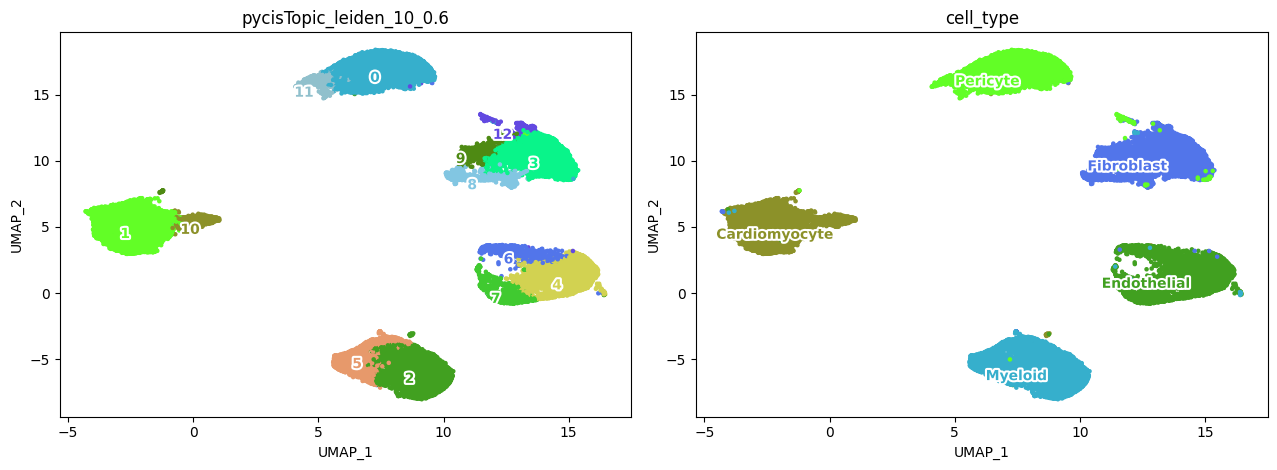

In [18]:
plot_metadata(
    cistopic_obj,
    reduction_name='UMAP',
    variables=['pycisTopic_leiden_10_0.6', 'cell_type'],
    target='cell', num_columns=4,
    text_size=10,
    dot_size=5)

### Plot by the sex and age status

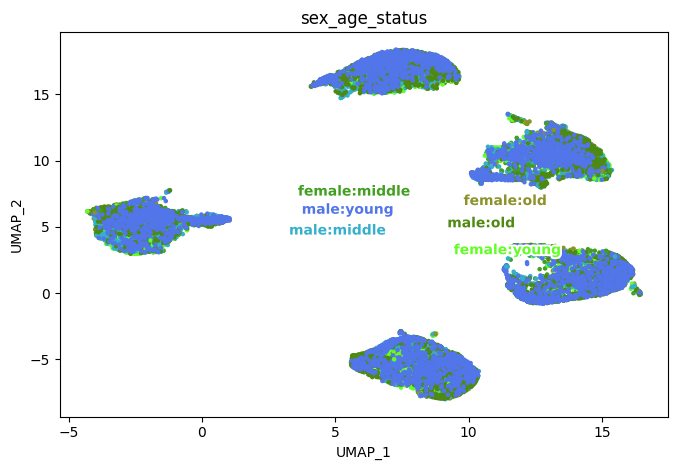

In [18]:
plot_metadata(
    cistopic_obj,
    reduction_name='UMAP',
    variables=['sex_age_status'],
    target='cell', num_columns=4,
    text_size=10,
    dot_size=5)